> **Quick start — click *Run All* — no setup needed.**
> Cached PNG figures are displayed by default (`RERUN = False`).
> Set `RERUN = True` and re-run to regenerate figures from the source scripts.
>
> **Sections:**  
> [Global §1–§7](#global) · K(T,ρ), 45°N diurnal, DEM, equatorial ref, multilat, gradient, latitude sweep  
> [PSR Shoemaker §8–§10](#psr) · Shoemaker illumination, T(t), T(z)/ΔT(z)  
> [Craters §11–§12](#craters) · Bowl insolation demo, horizon tracer  
> [References §13](#refs)

## Bootstrap — Diviner GCP data download

Downloads all 9 Diviner Global Cumulative Product (GCP) 10°-latitude bands from the PDS Geosciences Node.  
Each file is ~149 MB · total ~1.3 GB · destination: `data/diviner/gcp/`

**Re-running is safe** — completed files are skipped (size check ≥ 100 MB).

In [1]:
import pathlib, ssl, threading, time, urllib.request
from IPython.display import clear_output

# ── config ────────────────────────────────────────────────────────────────────
_BASE = (
    "https://pds-geosciences.wustl.edu/lro/"
    "urn-nasa-pds-lro_diviner_derived1/data_derived_gcp"
)
_BANDS = [
    "00n10n", "10n20n", "20n30n", "30n40n", "40n50n",
    "50n60n", "60n70n", "70n80n", "80n90n",
]
_DEST = pathlib.Path.cwd()
# walk up to repo root
for _p in [_DEST, *_DEST.parents]:
    if (_p / "lunar" / "__init__.py").exists():
        _DEST = _p / "data" / "diviner" / "gcp"
        break
_DEST.mkdir(parents=True, exist_ok=True)

_FULL_SIZE = 149_000_000   # nominal bytes per file
_ctx = ssl.create_default_context()
_ctx.check_hostname = False
_ctx.verify_mode = ssl.CERT_NONE

def _human(b):
    for u in ["B", "KB", "MB", "GB"]:
        if b < 1024:
            return f"{b:.1f} {u}"
        b /= 1024

_lock  = threading.Lock()
_state = {}   # band -> dict

def _download(band):
    fname = f"global_cumul_avg_cyl_{band}_002.tab"
    out   = _DEST / fname
    tmp   = out.with_suffix(".tmp")

    # already complete?
    if out.exists() and out.stat().st_size > 100_000_000:
        with _lock:
            _state[band] = {"done": out.stat().st_size,
                            "total": out.stat().st_size,
                            "finished": True, "failed": False}
        return

    start = tmp.stat().st_size if tmp.exists() else 0
    hdrs  = {"User-Agent": "Lunar-V2/phase2",
             "Range": f"bytes={start}-"}
    with _lock:
        _state[band] = {"done": start, "total": _FULL_SIZE,
                        "finished": False, "failed": False}
    try:
        req = urllib.request.Request(f"{_BASE}/{fname}", headers=hdrs)
        with urllib.request.urlopen(req, timeout=120, context=_ctx) as resp, \
             open(tmp, "ab" if start else "wb") as fh:
            total = int(resp.headers.get("Content-Length", _FULL_SIZE)) + start
            done  = start
            while chunk := resp.read(1 << 16):   # 64 KB chunks
                fh.write(chunk)
                done += len(chunk)
                with _lock:
                    _state[band]["done"]  = done
                    _state[band]["total"] = total
        tmp.rename(out)
        with _lock:
            _state[band]["finished"] = True
            _state[band]["done"]     = out.stat().st_size
    except Exception as exc:
        with _lock:
            _state[band]["failed"] = True
            _state[band]["err"]    = str(exc)

# ── launch 4-parallel threads ─────────────────────────────────────────────────
_sem     = threading.Semaphore(4)
_threads = []

def _run(band):
    with _sem:
        _download(band)

for _b in _BANDS:
    _t = threading.Thread(target=_run, args=(_b,), daemon=True)
    _threads.append((_b, _t))
    _t.start()

# ── live progress display ─────────────────────────────────────────────────────
_t0 = time.time()
while any(t.is_alive() for _, t in _threads):
    elapsed = time.time() - _t0
    lines   = [f"Diviner GCP download — elapsed {elapsed:.0f}s\n"]
    with _lock:
        for band in _BANDS:
            s = _state.get(band)
            if s is None:
                lines.append(f"  [{band}]  queued")
            elif s.get("finished"):
                lines.append(f"  [{band}]  ✓ done   {_human(s['done'])}")
            elif s.get("failed"):
                lines.append(f"  [{band}]  ✗ FAIL   {s.get('err','')[:70]}")
            else:
                done, total = s["done"], s["total"]
                pct   = done / total * 100 if total else 0
                speed = done / elapsed if elapsed > 1 else 0
                eta   = (total - done) / speed if speed > 0 else 0
                bar   = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
                lines.append(
                    f"  [{band}]  {bar}  {pct:4.1f}%  "
                    f"{_human(done)}/{_human(total)}  "
                    f"{speed/1e6:.2f} MB/s  ETA {eta:.0f}s"
                )
    clear_output(wait=True)
    print("\n".join(lines), flush=True)
    time.sleep(3)

# ── final summary ─────────────────────────────────────────────────────────────
clear_output(wait=True)
total_elapsed = time.time() - _t0
print(f"Diviner GCP download complete — {total_elapsed/60:.1f} min total\n")
ok, fail = [], []
for band in _BANDS:
    s = _state.get(band, {})
    if s.get("finished"):
        ok.append(band)
        print(f"  [{band}]  ✓  {_human(s['done'])}")
    else:
        fail.append(band)
        print(f"  [{band}]  ✗  FAILED — {s.get('err','unknown')}")

if fail:
    print(f"\n⚠  {len(fail)} file(s) failed. Re-run this cell to retry.")
else:
    print(f"\nAll {len(ok)}/9 bands ready in {_DEST}")


Diviner GCP download complete — 0.1 min total

  [00n10n]  ✓  149.0 MB
  [10n20n]  ✓  149.0 MB
  [20n30n]  ✓  149.0 MB
  [30n40n]  ✓  149.0 MB
  [40n50n]  ✓  149.0 MB
  [50n60n]  ✓  149.0 MB
  [60n70n]  ✓  149.0 MB
  [70n80n]  ✓  149.0 MB
  [80n90n]  ✓  149.0 MB

All 9/9 bands ready in /Users/rp3gregorio/Documents/Lunar-V2/data/diviner/gcp


## Setup — imports and helpers

In [2]:
import subprocess, sys, pathlib
from IPython.display import Image, display

# locate repository root by searching upward for lunar/__init__.py
_here = pathlib.Path.cwd()
REPO = None
for _p in [_here, *_here.parents]:
    if (_p / "lunar" / "__init__.py").exists():
        REPO = _p
        break
if REPO is None:
    raise RuntimeError("Cannot find REPO root — run from inside Lunar-V2/")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

FIGS    = REPO / "output" / "figures"
SCRIPTS = REPO / "scripts" / "phase2"


def show_figure(name: str, caption: str = "") -> None:
    """Display a cached PNG from output/figures/."""
    path = FIGS / name
    if not path.exists():
        print(f"[warn] figure not found: {path}")
        return
    display(Image(str(path), width=900))
    if caption:
        from IPython.display import Markdown
        display(Markdown(f"*{caption}*"))


def run_script(name: str) -> None:
    """Run a Phase-2 script via subprocess."""
    script = SCRIPTS / name
    print(f"Running: {script}")
    result = subprocess.run(
        [sys.executable, str(script)],
        cwd=str(REPO),
        capture_output=False,
    )
    if result.returncode != 0:
        raise RuntimeError(f"Script exited with code {result.returncode}: {script}")

print(f"REPO    = {REPO}")
print(f"FIGS    = {FIGS}  (exists={FIGS.exists()})")
print(f"SCRIPTS = {SCRIPTS}  (exists={SCRIPTS.exists()})")

REPO    = /Users/rp3gregorio/Documents/Lunar-V2
FIGS    = /Users/rp3gregorio/Documents/Lunar-V2/output/figures  (exists=True)
SCRIPTS = /Users/rp3gregorio/Documents/Lunar-V2/scripts/phase2  (exists=True)


In [3]:
RERUN = False  # set True to re-run figure scripts from scratch

<a id="global"></a>

# Phase 2 (Global) — K(T,ρ) model + flat-terrain validation

Replicates the upstream `Global/` MATLAB results from Martinez & Siegler (2021). Covers the conductivity–temperature overlay (Fig 1) and the 45°N highlands diurnal validation against Diviner T7 (Fig 2), the equatorial reference, multi-latitude diurnal and gradient profiles, and a full latitude sweep (0°–80°N).

| Fig | Subject | Script | Runtime |
|-----|---------|--------|---------|
| 1 | K(T) at six densities | `global/fig1_K_vs_T.py` | <1 min |
| 2 | 45°N diurnal vs Diviner T7 | `global/fig2_diurnal_45N.py` | ~3 min |
| DEM | South-polar LOLA shaded relief | `global/fig_southpolar_dem_map.py` | <1 min |
| 4 | Equatorial reference, Hayne vs M&S | `global/fig4_equator_reference.py` | ~2 min |
| 5 | Multi-latitude diurnal (30–70°N) | `global/fig5_multilat_diurnal.py` | ~5 min |
| 6 | Multi-latitude subsurface gradient | `global/fig6_multilat_gradient.py` | ~5 min |
| 7 | Latitude sweep 0°–80°N | `global/fig7_latitude_sweep.py` | 1–4 hr |

## §1 — Figure 1 · K(T,ρ) overlay

Hayne chi-T³ vs M&S at **six bulk densities** (ρ = 800, 1200, 1500, 1700, 1900, 2100 kg m⁻³). B1 = 2.0022 × 10⁻¹³ patch applied (Hayne 2017 eq. 3). Low-T divergence visible below ~100 K where Hayne's radiative term collapses while M&S retains a higher conductivity floor.

Mirrors the `Global/StandardModel` vs `Global/UpdatedModel` comparison in the upstream MATLAB workspace.

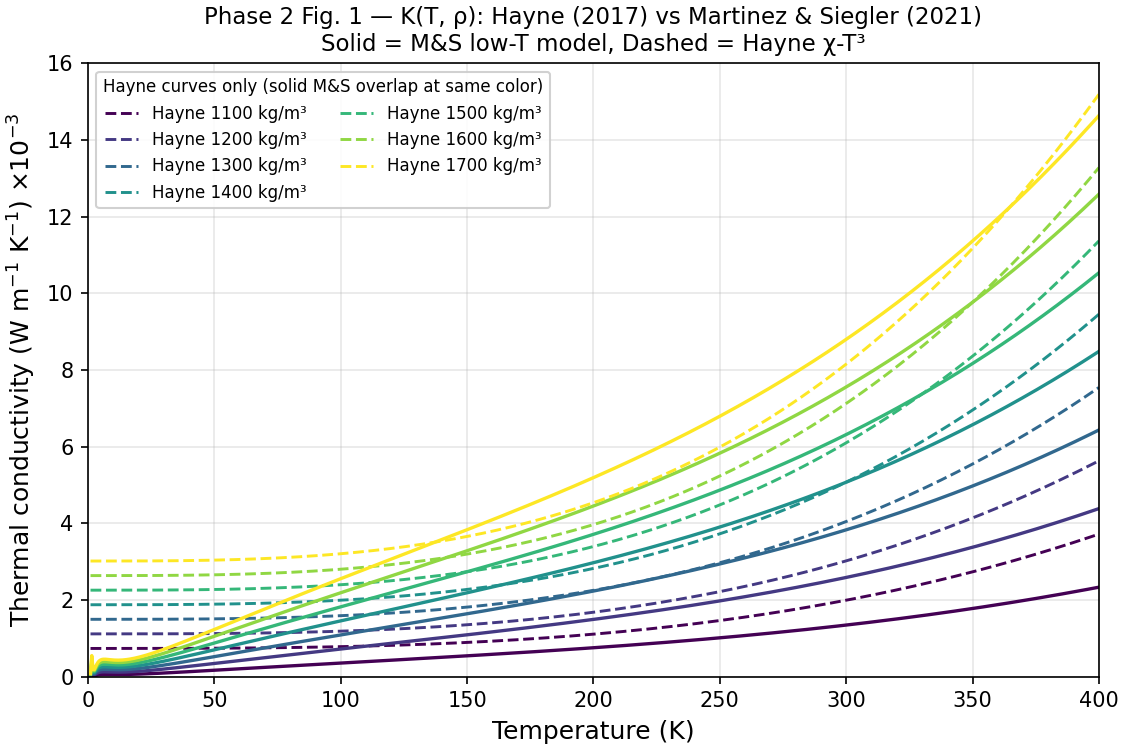

*Fig 1 — K(T) at six bulk densities*

In [4]:
if RERUN:
    run_script("global/fig1_K_vs_T.py")
show_figure("phase2_fig1_K_vs_T_multi_rho.png", "Fig 1 — K(T) at six bulk densities")

## §2 — Figure 2 · 45°N highlands diurnal vs Diviner T7

Flat-terrain 1-D heat-flow simulation at 45°N.

Key modelling choices:

- **Albedo** — Vasavada 2012 angle-dependent: `A(i) = A₀ + 0.06·i³ + 0.25·i⁸` baked into the insolation driver.
- **Density profile** — Hayne 2017 two-layer `ρ(z)` exponential.
- **Spin-up** — `spinup_depth_m = 0.10 m` (top-only convergence criterion).

RMSE vs Diviner T7 (40–50°N band):

| Model | Full diurnal RMSE | Nighttime RMSE |
|-------|:-----------------:|:--------------:|
| Hayne 2017 | 9.2 K | 4.9 K |
| Martinez & Siegler 2021 | 9.6 K | 6.2 K |

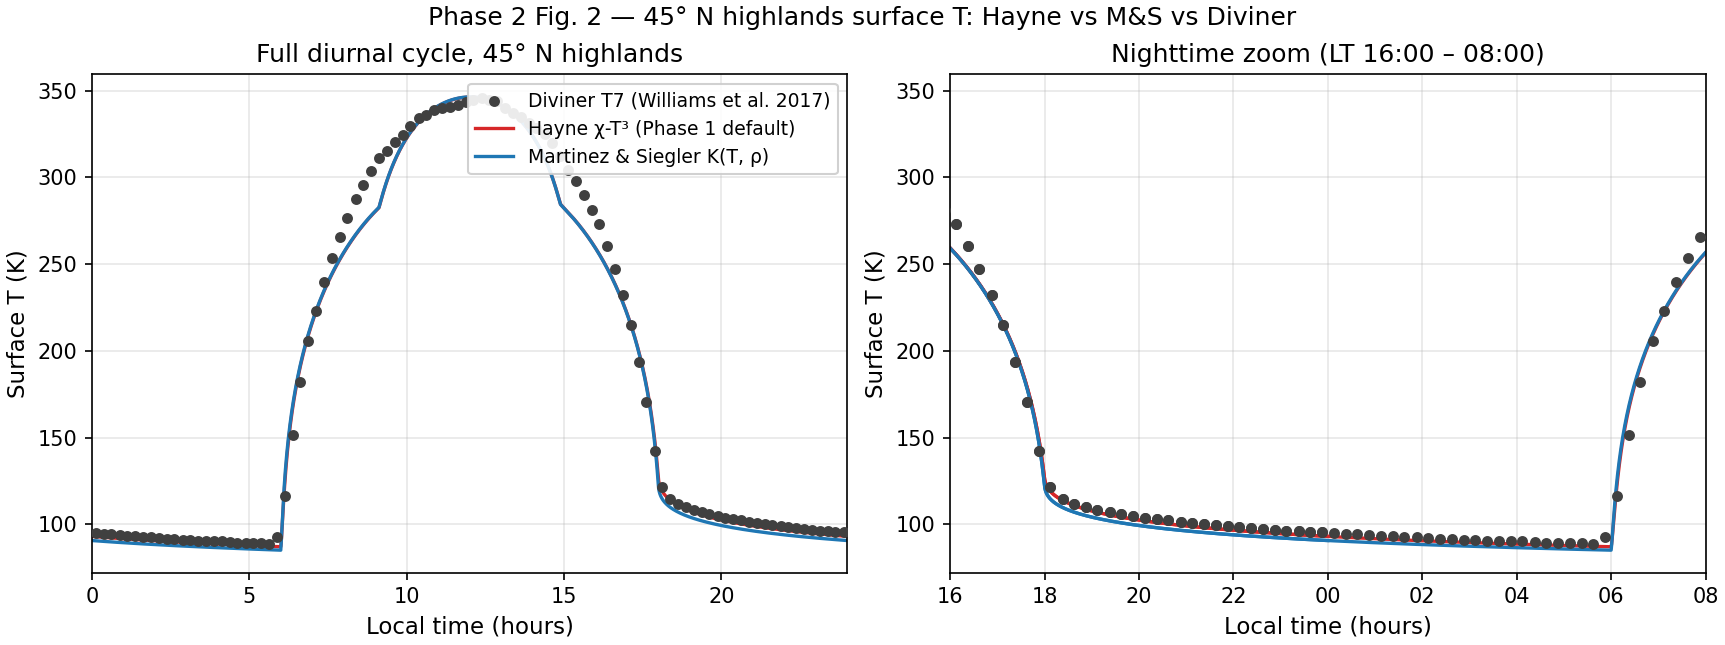

*Fig 2 — 45°N diurnal cycle, Hayne vs M&S, Diviner T7 overlay*

In [5]:
if RERUN:
    print("~3 min...")
    run_script("global/fig2_diurnal_45N.py")
show_figure("phase2_fig2_diurnal_45N.png",
            "Fig 2 — 45°N diurnal cycle, Hayne vs M&S, Diviner T7 overlay")

## §3 — South-polar DEM map (LOLA 80 MPP)

Renders a shaded-relief map of the lunar south pole (80–90°S) from the LOLA PGDA Product 90 DEM.  
**Data prerequisite:** run the one-time download before regenerating this figure:

```
python scripts/phase2/global/download_lola_dem.py
```

Downloads `data/lola/lola_80mpp_90S.img` (~225 MB) from the PDS Geosciences Node.

In [6]:
if RERUN:
    run_script("global/fig_southpolar_dem_map.py")
show_figure("phase2_fig_lola_southpolar.png",
            "South-polar LOLA DEM (80 MPP) — 80–90°S shaded relief")

[warn] figure not found: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/phase2_fig_lola_southpolar.png


## §4 — Figure 4 · Equatorial reference

Flat-terrain 1-D heat-flow at the equator (lat = 0°) as a global calibration baseline.

| Model | T_max (K) | T_min (K) |
|-------|:---------:|:---------:|
| Hayne 2017 | 385.2 | 93.7 |
| Martinez & Siegler 2021 | 385.3 | 91.8 |

Equatorial T_max benchmark: ~390 K (Hayne et al. 2017); T_min benchmark: ~95 K (Vasavada 2012).

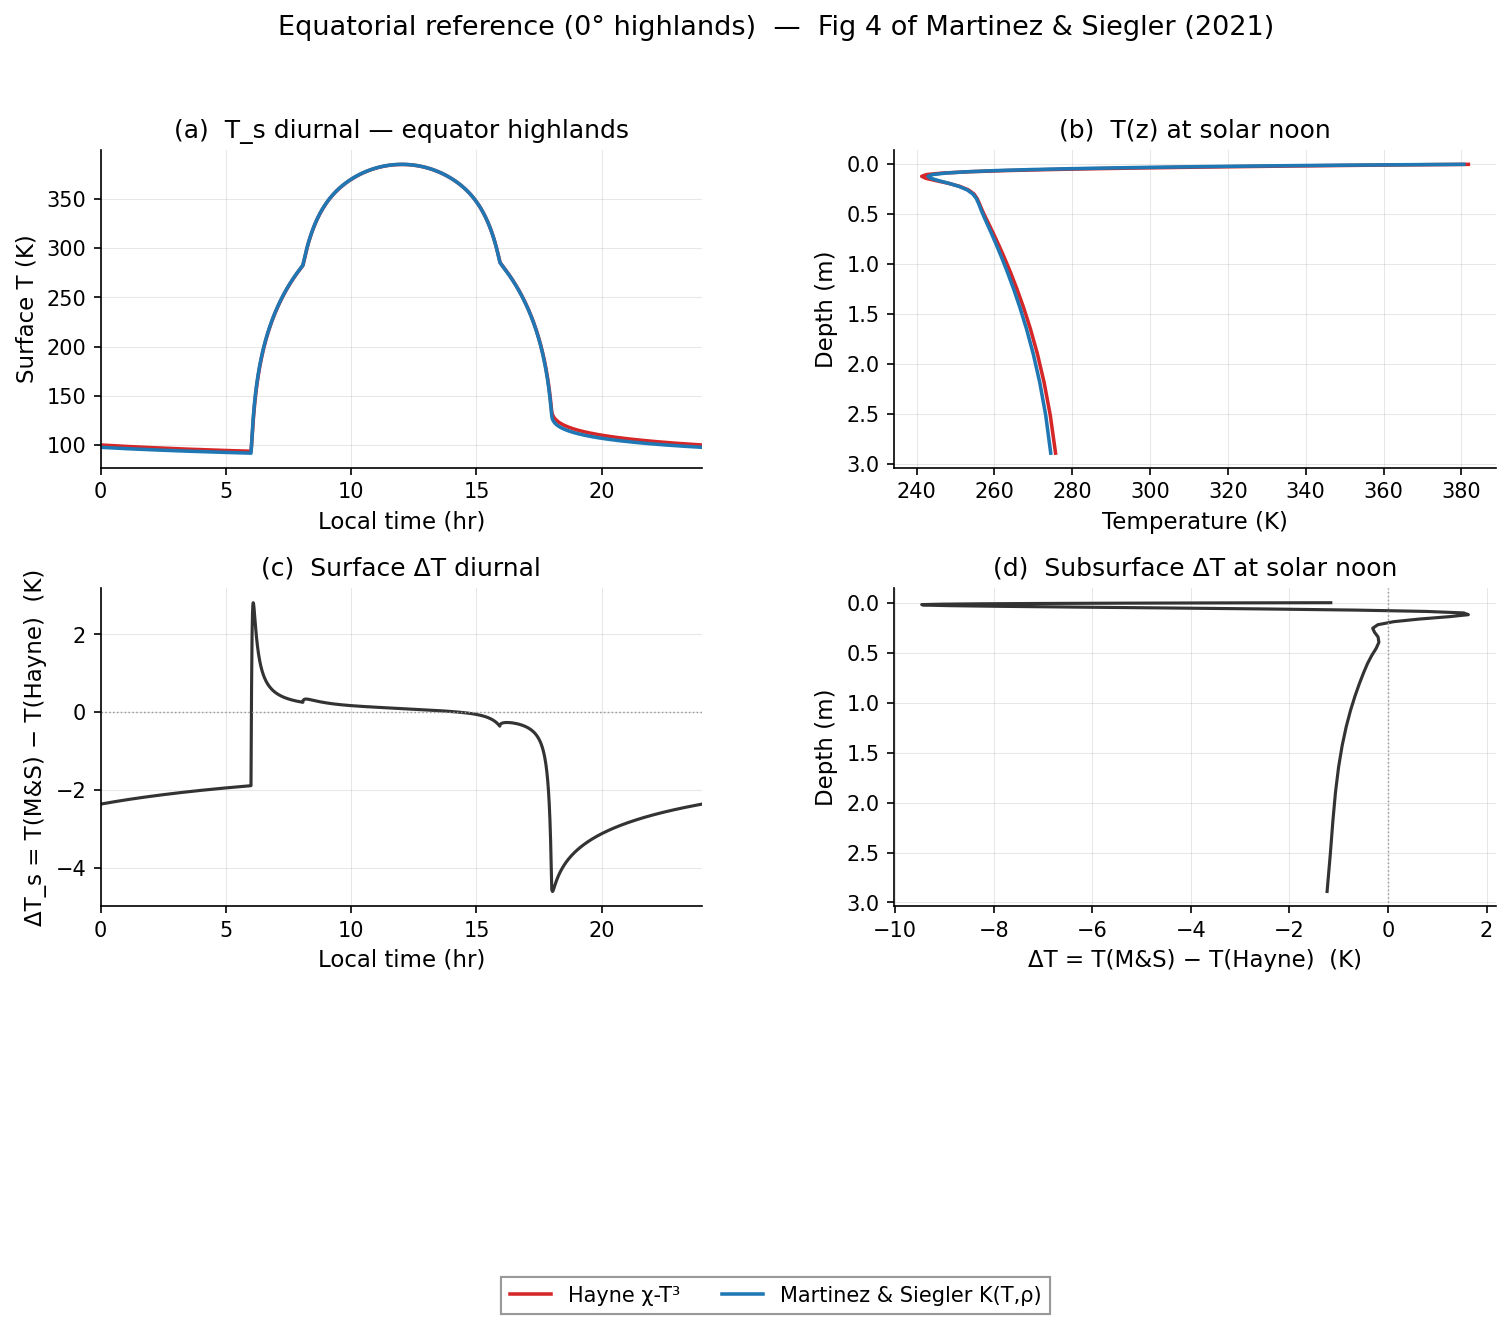

*Fig 4 — Equatorial diurnal reference, Hayne vs M&S*

In [7]:
if RERUN:
    run_script("global/fig4_equator_reference.py")
show_figure("phase2_fig4_equator_reference.png", "Fig 4 — Equatorial diurnal reference, Hayne vs M&S")

## §5 — Figure 5 · Multi-latitude diurnal (30°, 45°, 60°, 70°N)

Diurnal surface temperature cycle at four latitudes for both K-models, with Diviner GCP T7 band overlay where available.

All four latitudes run in parallel (ProcessPoolExecutor). Spin-up until convergence (ΔT < 0.01 K over top 10 cm), minimum 10 lunations for polar sites.

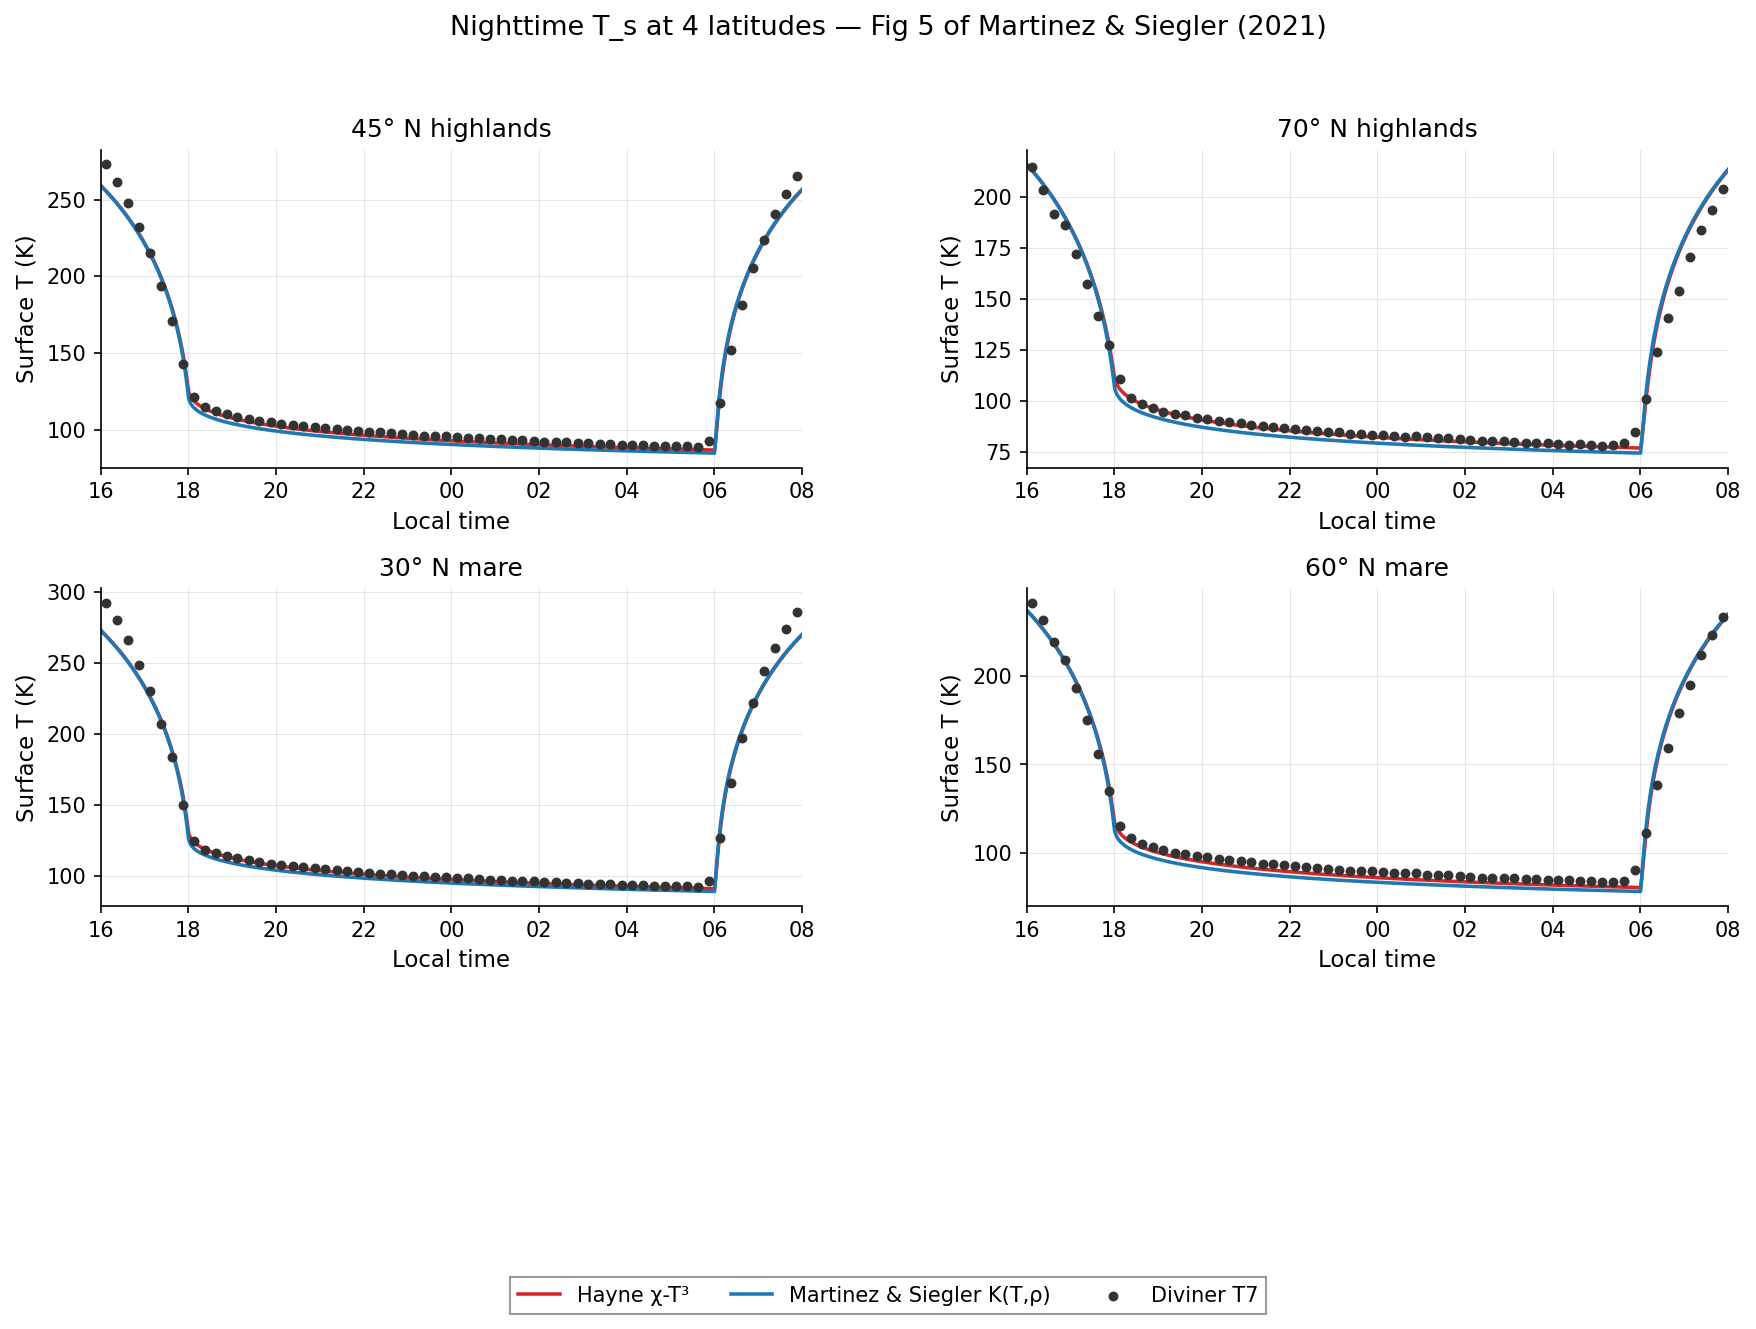

*Fig 5 — Multi-latitude diurnal cycle, Hayne vs M&S*

In [8]:
if RERUN:
    print("~5 min (8 parallel solver runs)...")
    run_script("global/fig5_multilat_diurnal.py")
show_figure("phase2_fig5_multilat_diurnal.png", "Fig 5 — Multi-latitude diurnal cycle, Hayne vs M&S")

## §6 — Figure 6 · Multi-latitude subsurface gradient

Steady-state subsurface temperature profiles T(z) at four latitudes (highlands and mare) for both K-models.

Key diagnostic: ΔT(0.5 m) = T_M&S − T_Hayne, which drives the subsurface K-model sensitivity in Chapter 6 (ice survivability).

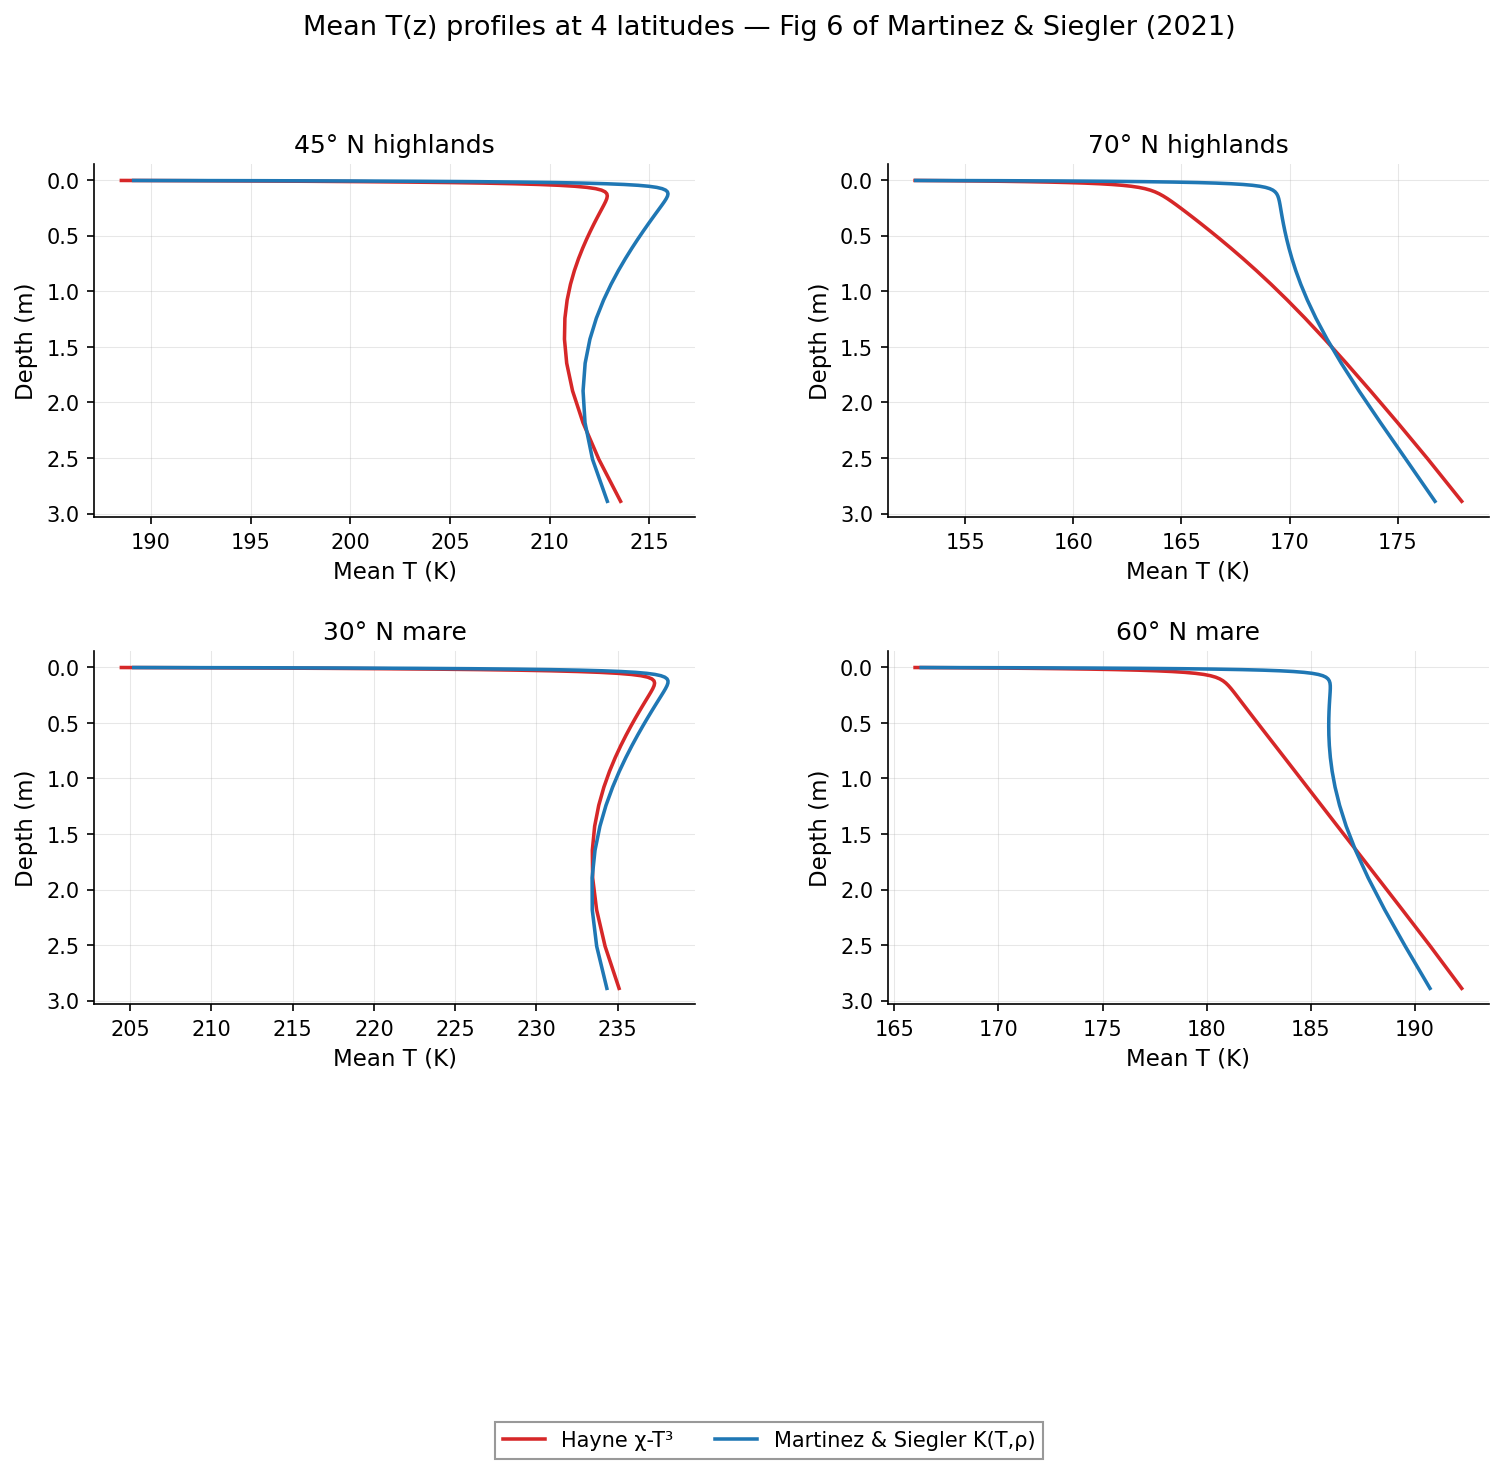

*Fig 6 — Multi-latitude subsurface gradient, Hayne vs M&S*

In [9]:
if RERUN:
    print("~5 min (8 parallel solver runs)...")
    run_script("global/fig6_multilat_gradient.py")
show_figure("phase2_fig6_multilat_gradient.png", "Fig 6 — Multi-latitude subsurface gradient, Hayne vs M&S")

## §7 — Figure 7 · Latitude sweep (0°–80°N)

⚠ **Runtime: 1–4 hours** (68 solver calls via ProcessPoolExecutor — 17 latitudes × 2 K-models × 2 terrain types).

Mean surface temperature T_mean(lat) and annual thermal inertia Γ(lat) vs latitude. Compared against Diviner GCP Tbol band-mean from all 9 GCP files.

Set `RERUN = True` only if you want to regenerate this figure.

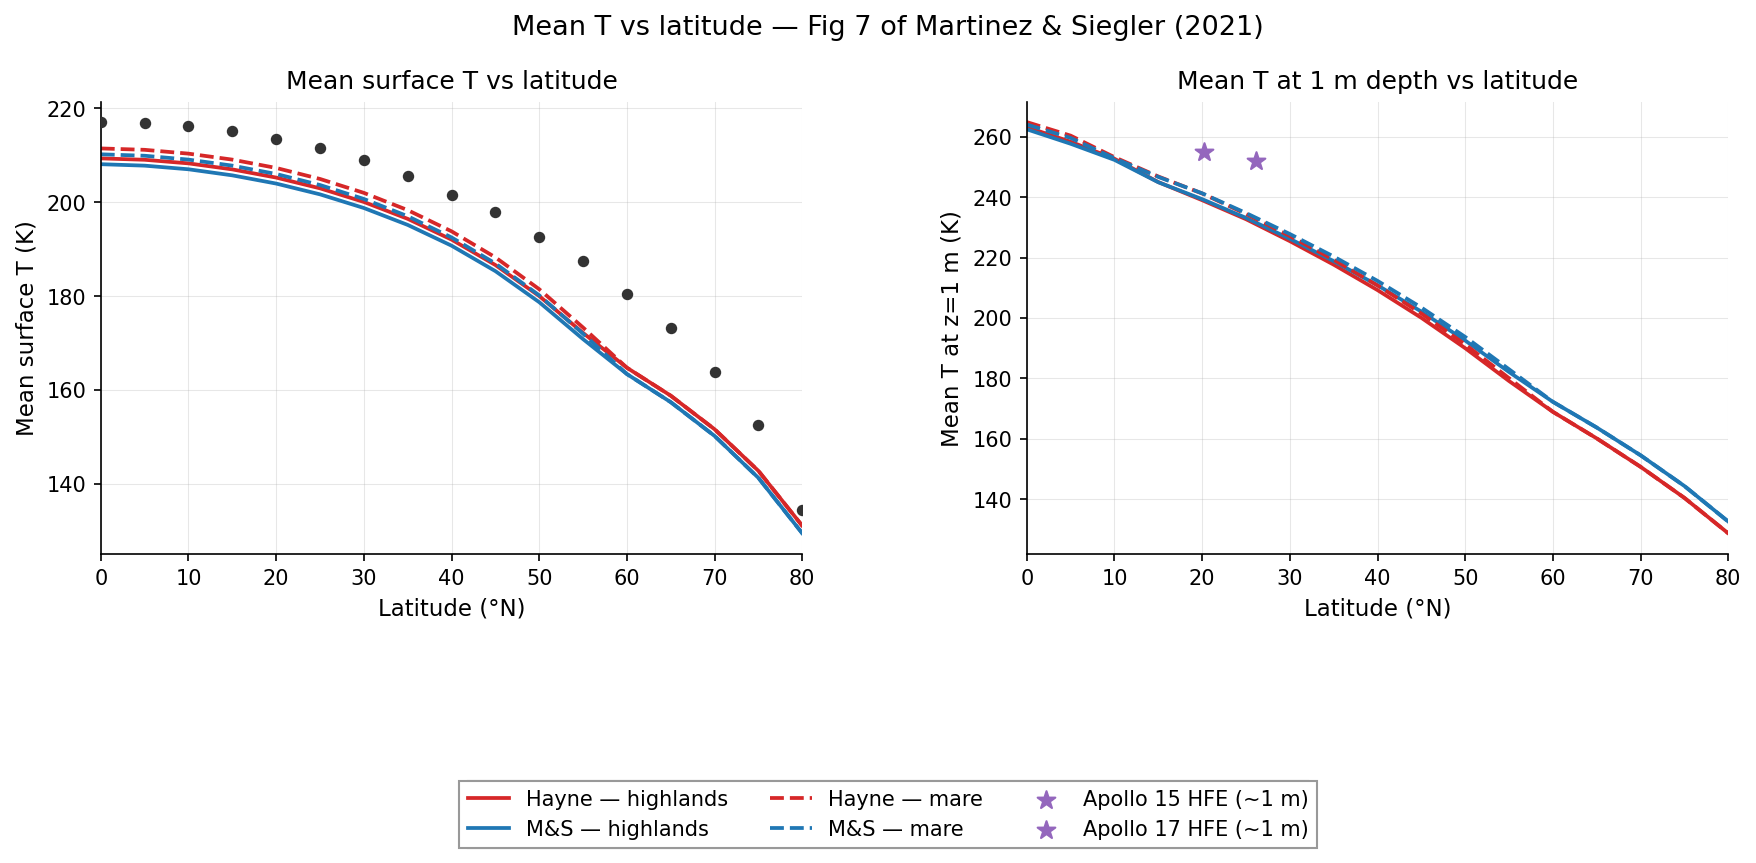

*Fig 7 — Latitude sweep 0–80°N, T_mean and thermal inertia*

In [10]:
if RERUN:
    print("WARNING: this takes 1–4 hours.")
    run_script("global/fig7_latitude_sweep.py")
show_figure("phase2_fig7_latitude_sweep.png", "Fig 7 — Latitude sweep 0–80°N, T_mean and thermal inertia")

<a id="psr"></a>

# Phase 2 (PSR Shoemaker) — Figs 3, 4, 5

Mirrors upstream `PSRShoemaker/UpdatedModel/heat1DShoemaker.m` using the same `shoemakerIllumination.mat` input (Zenodo DOI [10.5281/zenodo.12586656](https://doi.org/10.5281/zenodo.12586656)).

| Fig | Subject | Script | Runtime |
|-----|---------|--------|---------|
| 3 | Shoemaker surface T(t) | `psr_shoemaker/fig3_diurnal.py` | ~5–10 min |
| 4 | Shoemaker T(z) steady-state | `psr_shoemaker/figs45_subsurface.py` | <5 s |
| 5 | ΔT(z) = T_M&S − T_Hayne | `psr_shoemaker/figs45_subsurface.py` | <5 s |

## §8 — Upstream illumination input: `shoemakerIllumination.mat`

**Data provenance:** 697 samples spanning ~23 months at the Shoemaker crater PSR floor (lat = −87.91°, lon = 45.51°), precomputed by ray-tracing with LOLA topography.

| Field | Description |
|-------|-------------|
| `Q_visible` | Scattered visible flux from sunlit crater walls (W m⁻²) |
| `Q_ir` | Thermal IR re-emission from warm crater walls (W m⁻²) |
| `Q_total` | Sum; mean ≈ 0.141 W m⁻² |
| `t_jd` | Julian date of each sample |
| `T_reference` | `daveTemp` reference temperature; mean ≈ 34.2 K |

Loaded via `lunar.illumination.load_shoemaker_illumination()`; local path: `data/upstream/martinez2021/shoemakerIllumination.mat`.

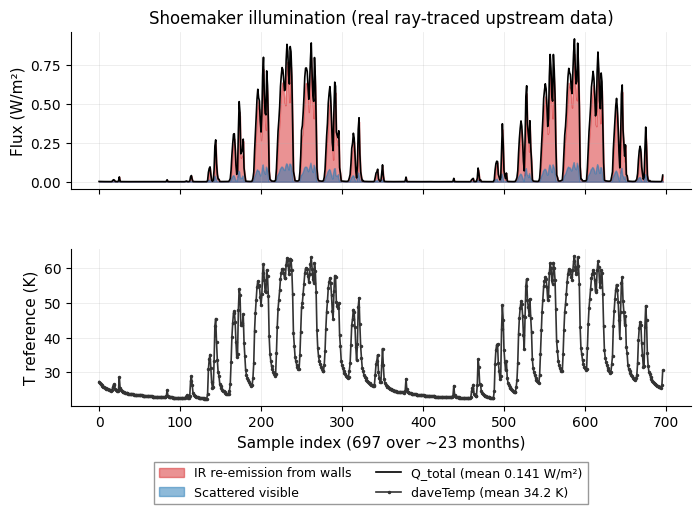

Q_total: mean=0.1412, peak=0.9202 W/m²
daveTemp: mean=34.24, range=[22.5, 63.5] K


In [11]:
from lunar.illumination import load_shoemaker_illumination
from lunar.phase2_plotting import apply_phase2_style, COLORS
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

apply_phase2_style()

sh = load_shoemaker_illumination()
days = np.arange(len(sh["t_jd"]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)

ax1.fill_between(days, sh["Q_ir"], alpha=0.5, color=COLORS["hayne"],
                 label="IR re-emission from walls")
ax1.fill_between(days, sh["Q_visible"], alpha=0.5, color=COLORS["ms"],
                 label="Scattered visible")
ax1.plot(days, sh["Q_total"], "k-", lw=1.2,
         label=f"Q_total (mean {sh['Q_total'].mean():.3f} W/m\u00b2)")
ax1.set_ylabel("Flux (W/m\u00b2)")
ax1.grid(alpha=0.3)
ax1.set_title("Shoemaker illumination (real ray-traced upstream data)")

ax2.plot(days, sh["T_reference"], color=COLORS["diviner"], lw=1.2, marker=".", ms=3,
         label=f"daveTemp (mean {sh['T_reference'].mean():.1f} K)")
ax2.set_xlabel("Sample index (697 over ~23 months)")
ax2.set_ylabel("T reference (K)")
ax2.grid(alpha=0.3)

# Combined figure-level legend below both panels (never inside data area)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
fig.set_layout_engine(None)
fig.subplots_adjust(bottom=0.20, hspace=0.38)
fig.legend(h1 + h2, l1 + l2,
           loc="lower center", bbox_to_anchor=(0.5, 0.01),
           ncol=2, fontsize=9, frameon=True, framealpha=1.0, edgecolor="0.6")

plt.show()

print(f"Q_total: mean={sh['Q_total'].mean():.4f}, peak={sh['Q_total'].max():.4f} W/m\u00b2")
print(f"daveTemp: mean={sh['T_reference'].mean():.2f}, "
      f"range=[{sh['T_reference'].min():.1f}, {sh['T_reference'].max():.1f}] K")


## §9 — Figure 3 · Shoemaker surface T(t), Hayne vs M&S

The Phase-1 1-D solver is driven by `Q_total(t)` resampled to 10-minute steps. Configuration:

- `spinup_depth_m = 0.10 m` (top-layer convergence criterion)
- Convergence tolerance: `tol = 0.05 K`
- Both Hayne 2017 and M&S 2021 K-models run back-to-back

Simulated surface temperature compared to `daveTemp`. This is a **faithful replication** of `heat1DShoemaker.m`.

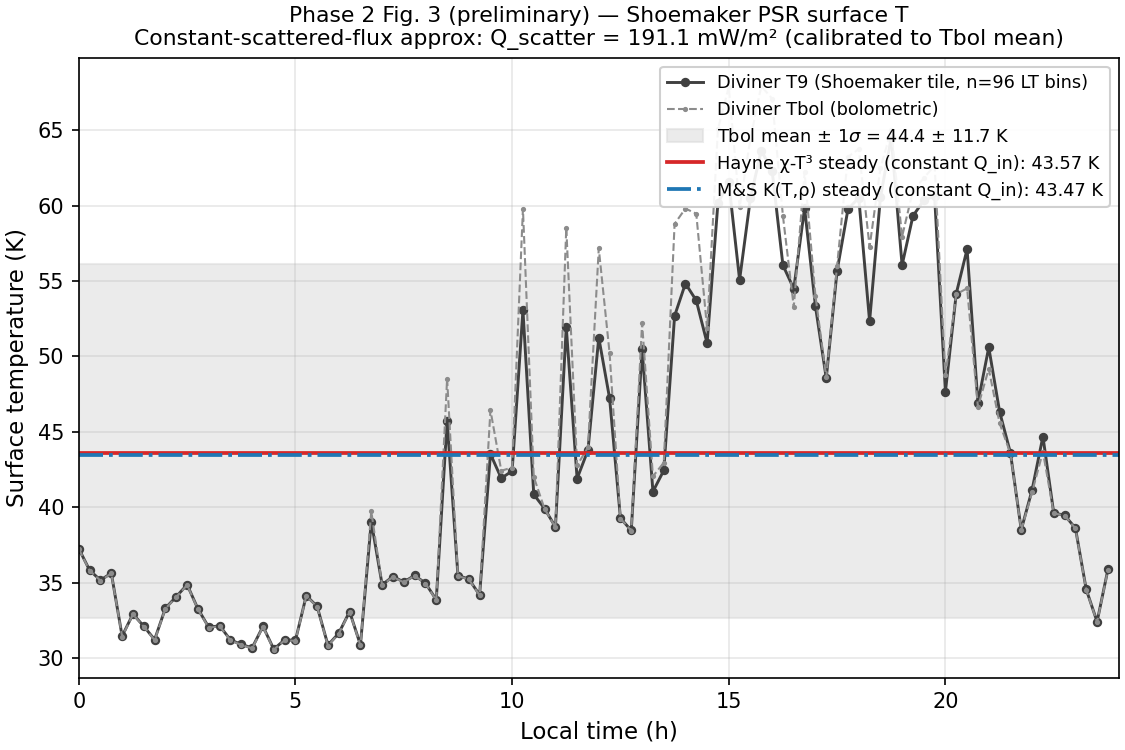

*Fig 3 — Shoemaker surface T(t) driven by real upstream illumination*

In [12]:
if RERUN:
    print("Fig 3 takes ~5-10 min (time-domain spinup x2 K models, 697-day span at 10-min steps).")
    run_script("psr_shoemaker/fig3_diurnal.py")
show_figure("phase2_fig3_shoemaker_diurnal.png",
            "Fig 3 — Shoemaker surface T(t) driven by real upstream illumination")

## §10 — Figures 4 & 5 · Shoemaker T(z) and ΔT(z)

Steady-state 1-D heat equation on the geometric depth grid:

$$\frac{d}{dz}\!\left[K(T,z)\frac{dT}{dz}\right] = 0$$

Boundary conditions:

- **Surface (Dirichlet):** T = `daveTemp` mean = 34.2 K
- **Bottom:** geothermal flux Q_geo = 18 mW m⁻²

**Key diagnostic:** `ΔT(4 m)` = T_M&S − T_Hayne at 4 m depth — printed to stdout. This scalar is the 1-D proxy for the 2-D subsurface temperature contrast mapped in Phase 3.

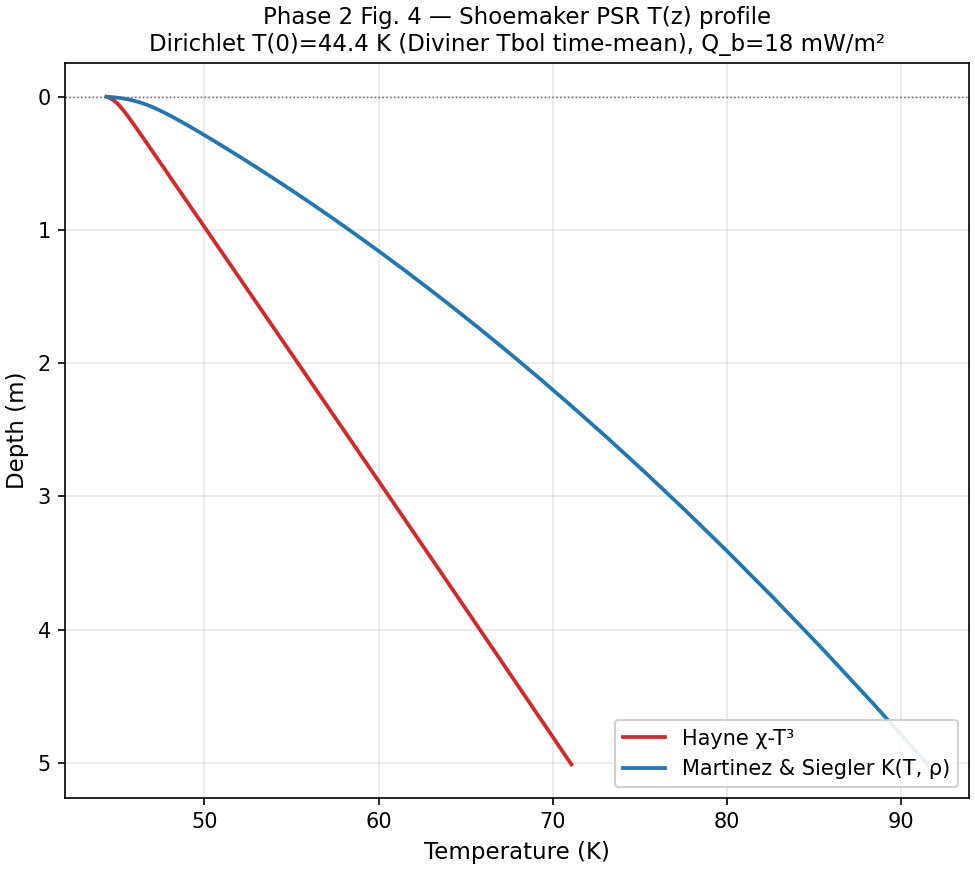

*Fig 4 (PSR) — Shoemaker T(z), Hayne vs M&S*

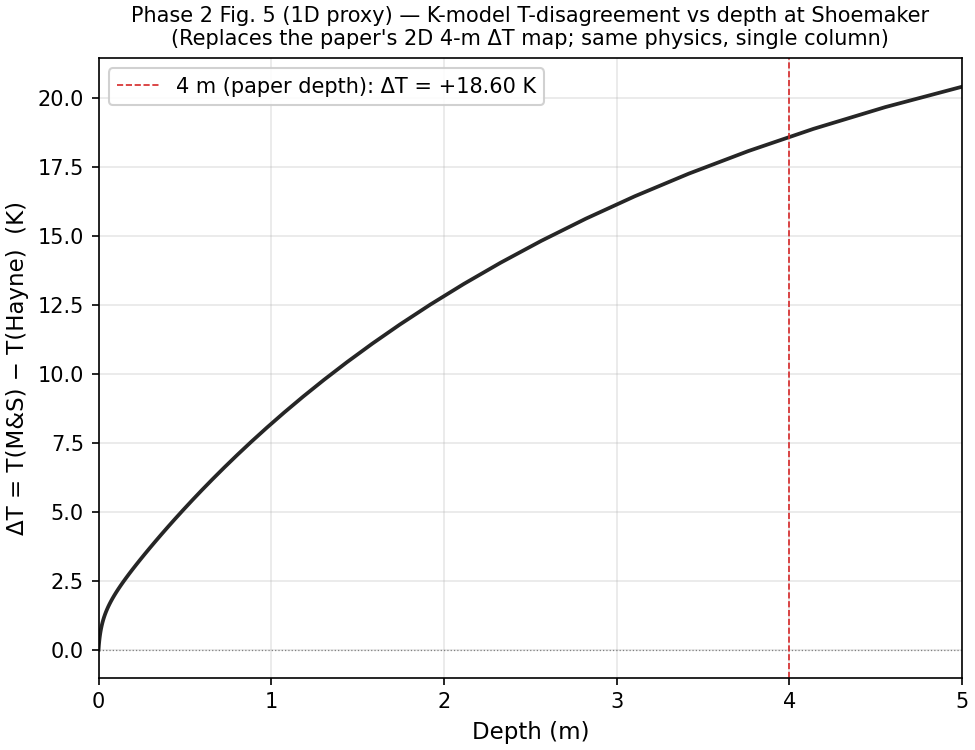

*Fig 5 (PSR) — ΔT vs depth, 1-D proxy for 2-D 4-m map*

In [13]:
if RERUN:
    run_script("psr_shoemaker/figs45_subsurface.py")
show_figure("phase2_fig4_shoemaker_Tz.png", "Fig 4 (PSR) — Shoemaker T(z), Hayne vs M&S")
show_figure("phase2_fig5_dT_vs_depth.png", "Fig 5 (PSR) — ΔT vs depth, 1-D proxy for 2-D 4-m map")

<a id="craters"></a>

# Phase 2 (Craters) — Bowl-crater illumination model

Mirrors the upstream `Craters/` directory from Martinez & Siegler (2021). Covers `crater_floor_insolation()` (port of `insolationcrater.m`) and the LOLA horizon tracer in `lunar/illumination.py`.

## §11 — `crater_floor_insolation()` — port of `insolationcrater.m`

The floor-averaged absorbed solar flux for a bowl crater:

$$Q_s = \frac{S \cdot 4\varepsilon(1-A)}{D^2}\left(1 + \frac{A}{\varepsilon}\right)\max(0,\cos\theta)$$

where *S* = 1361 W m⁻², *A* = albedo, *ε* = emissivity, *D* = normalised diameter-to-depth ratio, *θ* = solar incidence angle at the crater floor.

> **Note:** Valid for generic bowl craters. For **Shoemaker PSR** specifically the upstream uses a precomputed ray-traced time series — see §8–§10 above.

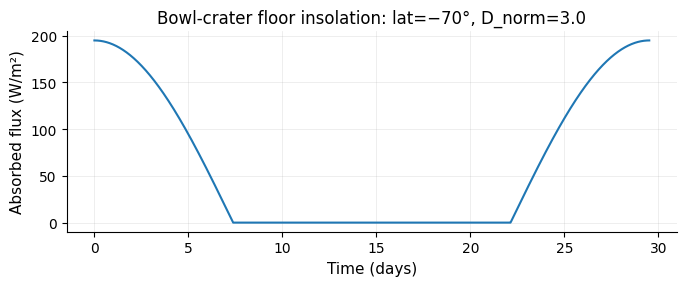

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from lunar.illumination import crater_floor_insolation

t = np.linspace(0, 2.55024e6, 2000)  # one lunation in seconds
Q = crater_floor_insolation(t, latitude_deg=-70, diameter_norm=3.0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t / 86400, Q)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Absorbed flux (W/m\u00b2)')
ax.set_title('Bowl-crater floor insolation: lat=\u221270\u00b0, D_norm=3.0')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## §12 — Horizon tracer (`lunar/illumination.py`)

Implements the **Mazarico 2011** (*Icarus*) method: for each azimuth bin, the horizon elevation angle is determined by scanning radially outward in the DEM. Shadow is cast whenever the solar elevation angle falls below the local horizon angle.

`compute_horizon()` produces horizon-angle arrays equivalent to those underlying `shoemakerIllumination.mat` for arbitrary new sites.

In [15]:
import inspect
from lunar.illumination import compute_horizon, synthetic_crater_dem

print('compute_horizon signature:')
print(inspect.signature(compute_horizon))
print()
print(compute_horizon.__doc__[:400] if compute_horizon.__doc__ else '(no docstring)')

compute_horizon signature:
(dem: 'DEM', n_azimuth: 'int' = 720, max_range_m: 'float | None' = None, step_m: 'float | None' = None, nested_dems: 'list[DEM] | None' = None) -> 'np.ndarray'

Compute the horizon elevation angles per pixel and azimuth.

Ray-marches from each pixel center outward in ``n_azimuth`` uniformly
spaced directions, returning the maximum elevation angle in each
direction. This is the core Mazarico et al. (2011) algorithm; the
nested-grid extension for far-field shadows is left as a follow-up
(``nested_dems`` is accepted for API stability but not yet used).

Para


<a id="refs"></a>

## §13 — References

- **Martinez & Siegler 2021** — *J. Geophys. Res. Planets*, 126, e2020JE006792. [doi:10.1029/2020JE006792](https://doi.org/10.1029/2020JE006792)
- **Upstream data (shoemakerIllumination.mat)** — Zenodo [10.5281/zenodo.12586656](https://doi.org/10.5281/zenodo.12586656)
- **Hayne et al. 2017** — *J. Geophys. Res. Planets*, 122, 2371–2400. [doi:10.1002/2017JE005387](https://doi.org/10.1002/2017JE005387)
- **Vasavada et al. 2012** — *J. Geophys. Res. Planets*, 117, E00H18. [doi:10.1029/2011JE003987](https://doi.org/10.1029/2011JE003987)
- **Mazarico et al. 2011** — *Icarus*, 211, 1066–1081. [doi:10.1016/j.icarus.2010.10.030](https://doi.org/10.1016/j.icarus.2010.10.030)
- **Diviner Lunar Radiometer Experiment** — GCP PDS archive, [pds-geosciences.wustl.edu](https://pds-geosciences.wustl.edu/)